In [1]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn gradio -q

In [2]:
import pandas as pd
import numpy as np
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset

In [3]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df.head()

Saving phishing_email_dataset.csv to phishing_email_dataset.csv


,text,label
0,The department meeting is scheduled for tomorr...,0
1,Thank you for attending the workshop yesterday.,0
2,Your Office365 password has expired. Reset it ...,1
3,Your account has been suspended. Click the lin...,1
4,The library will remain closed on Sunday.,0


In [4]:
print(df.columns)
print(df.shape)
print(df['label'].value_counts())

Index(['text', 'label'], dtype='object')
(500, 2)
label
0    250
1    250
Name: count, dtype: int64


In [5]:
df = df.rename(columns={
    "Email Text": "text",
    "Email Type": "label"
})

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "URL", text)
    text = re.sub(r"\S+@\S+", "EMAIL", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean_text)
df = df.dropna()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [9]:
class EmailDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, y_train)
test_dataset = EmailDataset(test_encodings, y_test)

In [10]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none"
)

In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.398529,0.023429
2,0.004579,0.000507


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=100, training_loss=0.20155412584543228, metrics={'train_runtime': 228.0048, 'train_samples_per_second': 3.509, 'train_steps_per_second': 0.439, 'total_flos': 6166665360000.0, 'train_loss': 0.20155412584543228, 'epoch': 2.0})

In [14]:
predictions = trainer.predict(test_dataset)

y_pred_logits = predictions.predictions
y_pred = np.argmax(y_pred_logits, axis=1)

y_prob = torch.softmax(torch.tensor(y_pred_logits), dim=1)[:, 1].numpy()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

Accuracy : 100.0 %
Precision: 100.0 %
Recall   : 100.0 %
F1 Score : 100.0 %


In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Phishing"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00        50
    Phishing       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



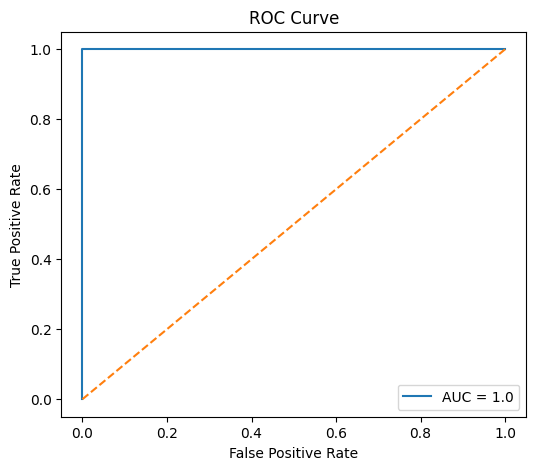

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 3)))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [18]:
model.save_pretrained("phishguard_bert_model")
tokenizer.save_pretrained("phishguard_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('phishguard_bert_model/tokenizer_config.json',
 'phishguard_bert_model/tokenizer.json')

In [19]:
!zip -r phishguard_bert_model.zip phishguard_bert_model
files.download("phishguard_bert_model.zip")

  adding: phishguard_bert_model/ (stored 0%)
  adding: phishguard_bert_model/tokenizer.json (deflated 71%)
  adding: phishguard_bert_model/tokenizer_config.json (deflated 43%)
  adding: phishguard_bert_model/config.json (deflated 53%)
  adding: phishguard_bert_model/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

suspicious_words = [
    "urgent", "verify", "password", "login", "bank", "account",
    "suspended", "blocked", "click", "payment", "card",
    "credentials", "security", "warning", "limited", "prize",
    "claim", "identity", "otp"
]

def find_suspicious_words(text):
    found = []
    text = text.lower()
    for word in suspicious_words:
        if word in text:
            found.append(word)
    return found

def predict_email(email_text):
    if email_text.strip() == "":
        return "No input", "0%", "Low", "Please enter email content."

    clean = clean_text(email_text)

    inputs = tokenizer(
        clean,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    confidence, predicted_class = torch.max(probs, dim=1)

    confidence_score = round(confidence.item() * 100, 2)

    if predicted_class.item() == 1:
        prediction = "Phishing"
    else:
        prediction = "Legitimate"

    if prediction == "Phishing" and confidence_score >= 85:
        risk = "High"
    elif prediction == "Phishing":
        risk = "Medium"
    else:
        risk = "Low"

    found_words = find_suspicious_words(email_text)

    report = f"""
Prediction: {prediction}

Confidence Score: {confidence_score}%

Risk Level: {risk}

Suspicious Words:
{", ".join(found_words) if found_words else "No major suspicious words found"}

Model Performance:
Accuracy: {round(accuracy * 100, 2)}%
Precision: {round(precision * 100, 2)}%
Recall: {round(recall * 100, 2)}%
F1 Score: {round(f1 * 100, 2)}%
"""

    return prediction, str(confidence_score) + "%", risk, report

In [22]:
app = gr.Interface(
    fn=predict_email,
    inputs=gr.Textbox(
        lines=10,
        label="Paste Email Content",
        placeholder="Paste email content here..."
    ),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Confidence Score"),
        gr.Textbox(label="Risk Level"),
        gr.Textbox(label="Full Report")
    ],
    title="PhishGuard: AI-Based Email Phishing Detection Using BERT",
    description="This system classifies emails as Legitimate or Phishing using BERT and displays confidence, risk level, and model performance.",
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2fa49d63ef1da5864d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
